# Decision Tree Classifier & Regressor on Security Dataset

This notebook applies **Decision Tree** models to a corporate cybersecurity dataset (`security_data_10000V2.csv`) containing 10,000 company records. The notebook is split into two parts:

1. **Decision Tree Classifier** — predicts whether a company is listed on the Stock Market (`Stock_Market`: Yes/No)
2. **Decision Tree Regressor** — predicts a continuous security metric (`Succ_Sec_Breaches`)

The dataset includes the following features:

| Column | Type | Description |
|---|---|---|
| `Sector` | Categorical | Industry sector (Banking, Health Care, Hospitality) |
| `CEO_Gender` | Categorical | Gender of the CEO |
| `Size` | Categorical | Company size (Small, Medium, Large) |
| `Security_Invest` | Numerical | Annual security investment ($) |
| `Security_Breach_Att` | Numerical | Number of breach attempts |
| `Succ_Sec_Breaches` | Numerical | Number of successful breaches |
| `Sec_Rating` | Categorical | Security rating (Low, Medium, High) |
| `CEO_Sec_Exp` | Categorical | CEO's security experience level |
| `LOT_in_Business` | Numerical | Years in business |
| `Stock_Market` | Categorical | Whether the company is publicly listed (target for classifier) |

## Part 1: Decision Tree Classifier

### Step 1 — Load the Dataset

The CSV is loaded into a pandas DataFrame. The `head()` call shows the first 5 rows so we can verify column names, data types, and that the file loaded correctly.

In [23]:
import pandas as pd

security_df = pd.read_csv("https://raw.githubusercontent.com/eddiejaques/ml-code-samples/refs/heads/main/Security%20Breaches%20Dataset/security_data_10000V2.csv")

print (security_df.head())

        Sector CEO_Gender    Size  Security_Invest  Security_Breach_Att  \
0  Hospitality       Male   Large               32                   60   
1  Health Care       Male   Small               56                   54   
2  Health Care       Male  Medium               24                   63   
3  Hospitality       Male  Medium               26                   42   
4      Banking       Male  Medium               23                   54   

   Succ_Sec_Breaches Sec_Rating CEO_Sec_Exp  LOT_in_Business Stock_Market  
0                 17     Medium         Low               11           No  
1                 17     Medium         Low               18          Yes  
2                 16       High         Low                5          Yes  
3                 18        Low         Low                3           No  
4                 19     Medium         Low                4          Yes  


### Step 2 — Train / Test Split

The dataset is split into a **training set (80%)** and a **test set (20%)** using `train_test_split`. `random_state=42` ensures the split is reproducible. The model will be trained on `security_df_train` and evaluated on `security_df_test` — data the model has never seen — to give an honest estimate of generalisation performance.

In [24]:
from sklearn.model_selection import train_test_split

security_df_train, security_df_test = train_test_split(security_df, test_size=0.2, random_state=42)

print(security_df_train.head())

           Sector CEO_Gender    Size  Security_Invest  Security_Breach_Att  \
9254  Health Care       Male   Large              133                   35   
1561      Banking       Male   Small               12                   51   
1670  Hospitality       Male  Medium               32                   26   
6087      Banking     Female   Large               43                   28   
6669      Banking       Male   Small               15                   18   

      Succ_Sec_Breaches Sec_Rating CEO_Sec_Exp  LOT_in_Business Stock_Market  
9254                  7     Medium         Low                6          Yes  
1561                 24        Low        High               10          Yes  
1670                 10        Low      Medium                2          Yes  
6087                  7        Low        High                7          Yes  
6669                  9        Low        High                4           No  


### Step 3 — Exploratory Data Analysis: Feature Distributions

Histograms are plotted for every numerical column in the training set. This reveals:
- The **range and spread** of each feature
- Potential **skewness** (e.g., heavy right-tail in `Security_Invest`)
- Whether any column might need scaling or transformation

Findings
1. All numeric data skewed to left
2. No visible outliers.


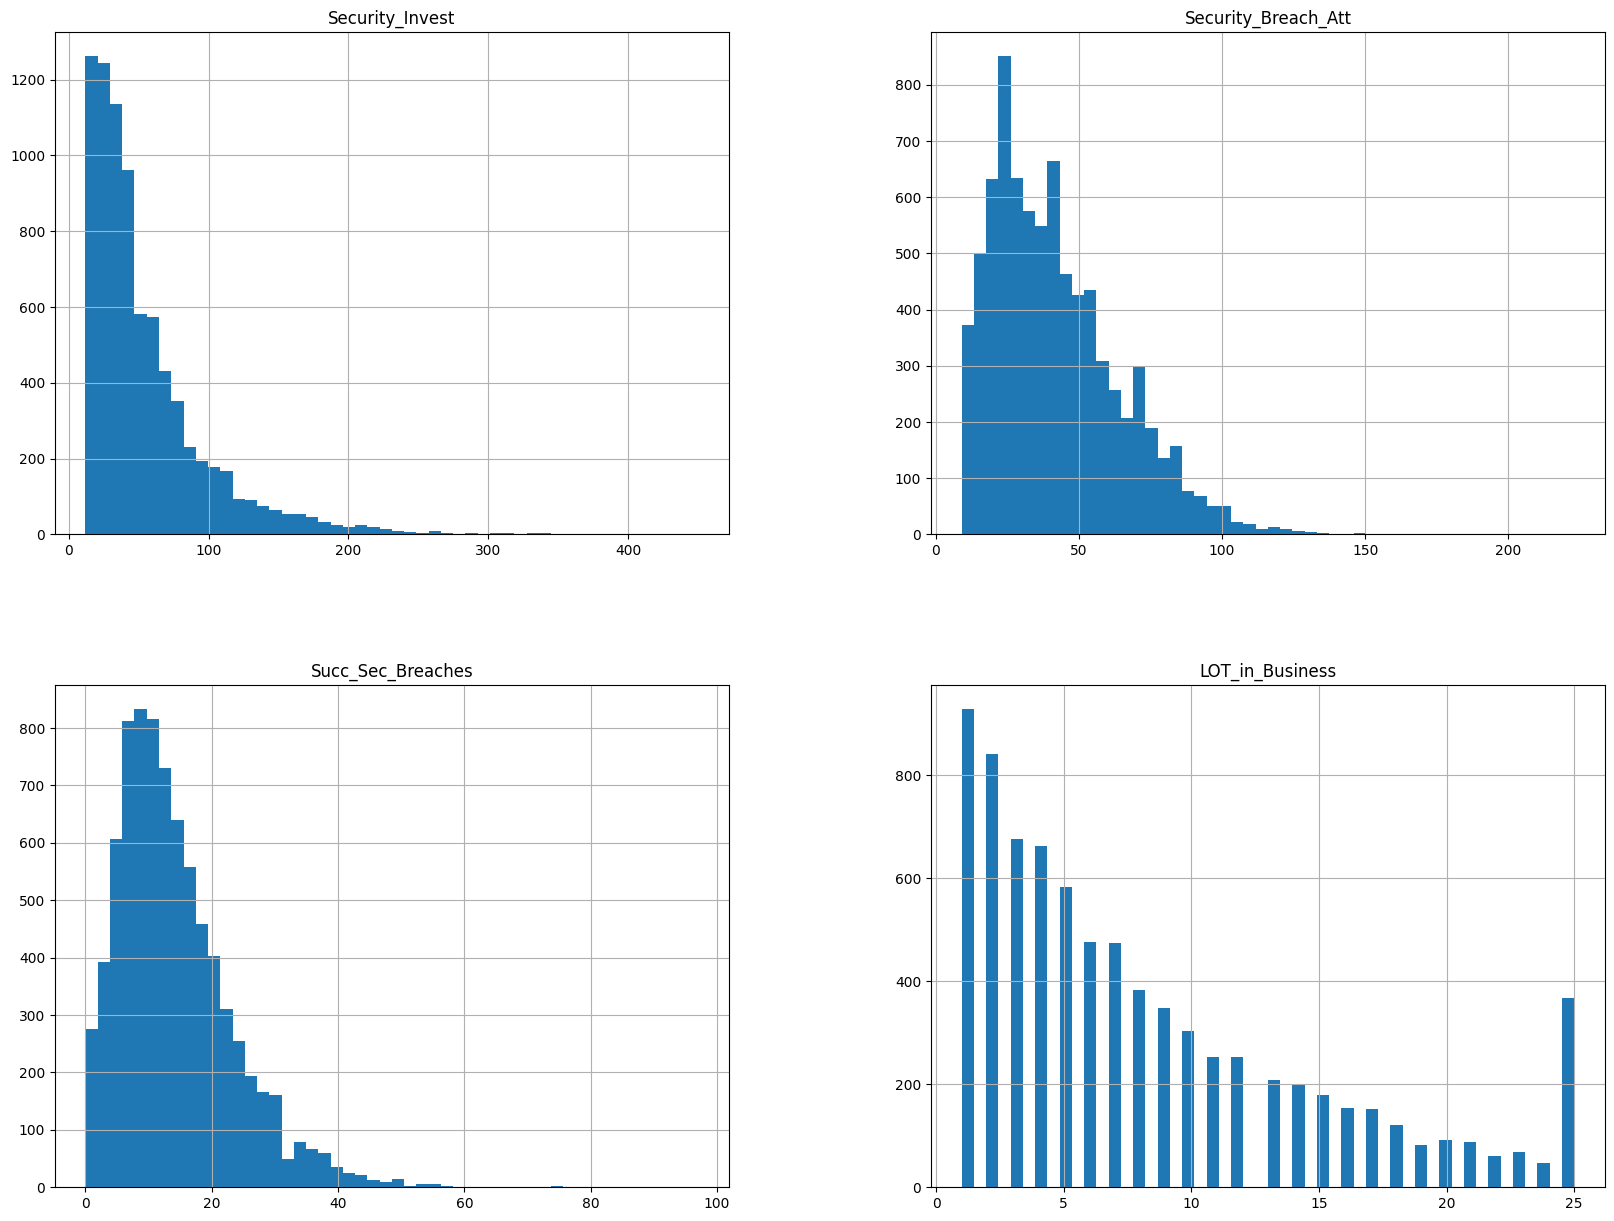

In [25]:
import matplotlib.pyplot as plt

security_df_train.hist(bins=50, figsize=(20,15))
plt.show()

### Step 4 — Check for Missing Values

`isna().sum()` counts `NaN` values in each column. All counts are zero, meaning the dataset is **complete with no missing data**. Even so, a `SimpleImputer` is applied later as a defensive preprocessing step — a best practice to ensure the pipeline is robust if new data arrives with gaps.

In [26]:
security_df_train.isna().sum()

,0
Sector,0
CEO_Gender,0
Size,0
Security_Invest,0
Security_Breach_Att,0
Succ_Sec_Breaches,0
Sec_Rating,0
CEO_Sec_Exp,0
LOT_in_Business,0
Stock_Market,0


### Step 5 — Exploratory Data Analysis: Scatter Matrix

A **scatter matrix** (also called a pair plot) visualises pairwise relationships between all columns. Each off-diagonal cell is a scatter plot between two features, and the diagonal shows each feature against itself. This helps identify:
- **Linear or non-linear correlations** between features
- **Clusters** that may hint at natural groupings
- **Outliers** that stand out from the main distribution

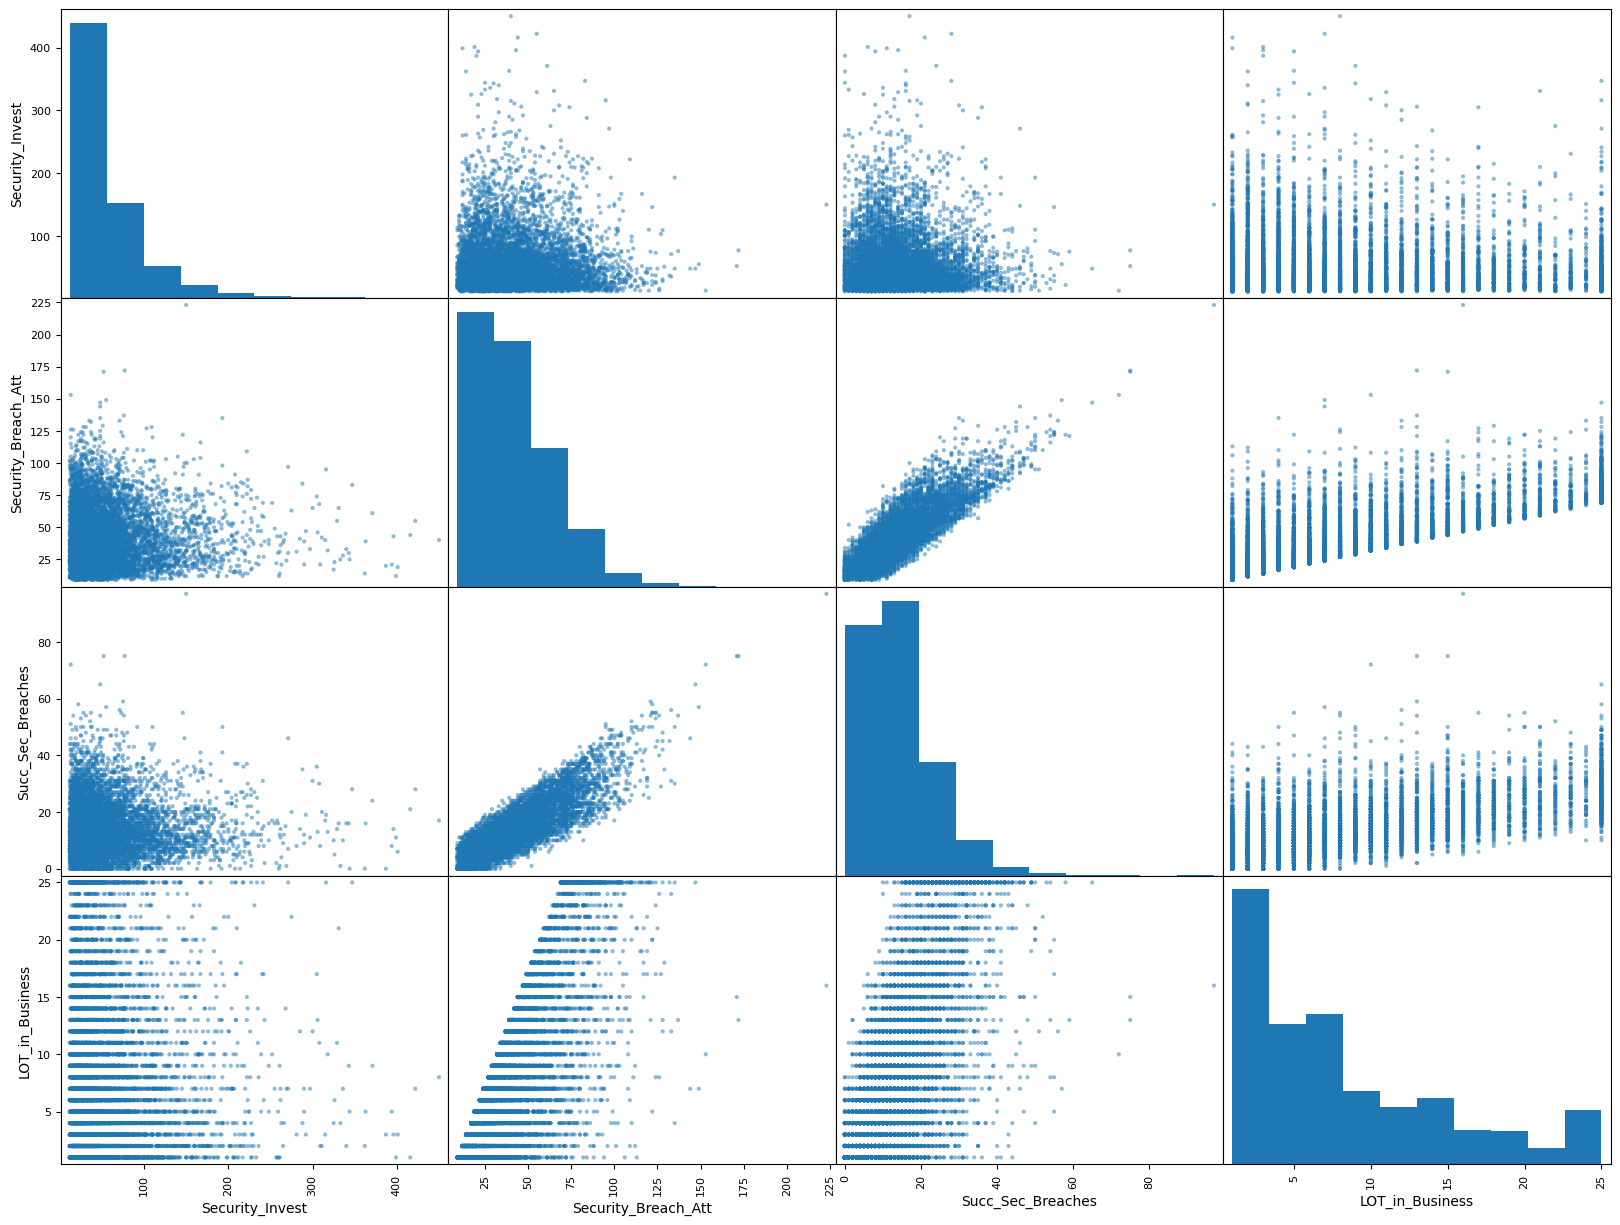

In [27]:
import matplotlib.pyplot as plt

# Create a scatter plot matrix of security dataset

pd.plotting.scatter_matrix(security_df_train, figsize=(20, 15))
plt.show()




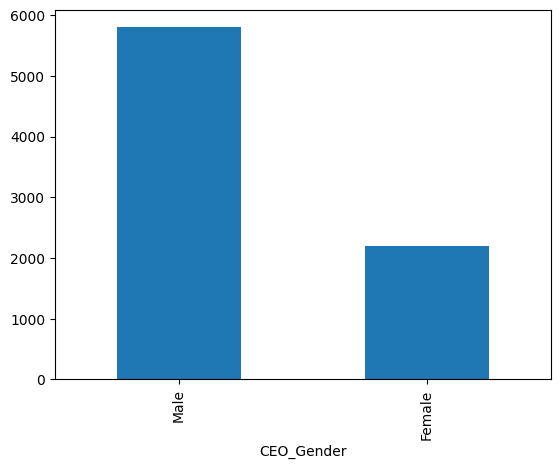

In [28]:
security_df_train["CEO_Gender"].value_counts().plot(kind="bar")
plt.show()

### Step 6 — Categorical Distribution: CEO Gender

The bar chart above shows the class balance of `CEO_Gender` in the training set — a heavily skewed distribution (e.g., 95% Male) could cause the model to ignore the minority class.

### Step 7 — Target Variable Distribution: Stock Market Listing

This bar chart shows the class balance of the **target variable** `Stock_Market` (Yes/No). A roughly 70/30 split (Yes/No) is visible. Knowing the class ratio is critical because:
- A severely imbalanced target can bias a classifier toward the majority class
- Accuracy alone becomes a misleading metric — precision, recall, and F1 are more informative

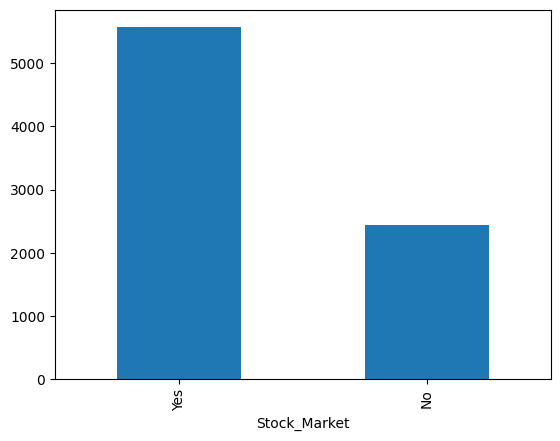

In [29]:
security_df_train["Stock_Market"].value_counts().plot(kind="bar")
plt.show()

### Step 8 — Impute Missing Values in Numerical Columns

Although no missing values were found, a `SimpleImputer` with `strategy="median"` is fitted on the **training set only** and then applied to both train and test sets. Key points:

- **Why median?** The median is robust to outliers, unlike the mean.
- **Why fit only on training data?** Fitting the imputer on the full dataset would introduce **data leakage** — the imputer would have information from test samples that should be unseen.
- Numerical and categorical columns are separated first (`select_dtypes`) since the imputer only works on numbers. The result is wrapped back into a DataFrame to preserve column names and the original index.

In [30]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(strategy="median")

security_df_train_num = security_df_train.select_dtypes(include=[np.number])
security_df_test_num = security_df_test.select_dtypes(include=[np.number])

imputer.fit(security_df_train_num)

security_df_train_tf = imputer.transform(security_df_train_num)
security_df_test_tf = imputer.transform(security_df_test_num)

security_df_train_tf = pd.DataFrame(security_df_train_tf,
                                     columns=security_df_train_num.columns,
                                     index=security_df_train_num.index)

security_df_test_tf  = pd.DataFrame(security_df_test_tf,
                                     columns=security_df_test_num.columns,
                                     index=security_df_test_num.index)



### Step 9 — One-Hot Encode Categorical Features

Scikit-learn models require purely numerical input. `pd.get_dummies` converts each categorical column into a set of binary (0/1) indicator columns — one per unique category value. For example, `Sector` with values Banking, Health Care, Hospitality becomes three columns: `Sector_Banking`, `Sector_Health Care`, `Sector_Hospitality`.

The same encoding is applied to both train and test sets. The final feature matrices are built by concatenating the imputed numerical columns with the one-hot encoded categorical columns. The resulting shape is **(8000 × 20)** for train and **(2000 × 20)** for test.

In [31]:
cat_cols = ['Sector', 'CEO_Gender' ,'Size', 'Sec_Rating', 'CEO_Sec_Exp','Stock_Market']
numerical_cols = security_df_train_num.columns

print("Categorical columns:", cat_cols)
print("Numerical columns:", numerical_cols)

security_df_train_cat = pd.get_dummies(security_df_train[cat_cols], dtype=int)
security_df_test_cat  = pd.get_dummies(security_df_test[cat_cols],  dtype=int)

security_df_test_cat.head()

security_df_train_final = pd.concat([security_df_train_tf, security_df_train_cat], axis=1)
security_df_test_final  = pd.concat([security_df_test_tf,  security_df_test_cat],  axis=1)

print('Final train shape:', security_df_train_final.shape)
print('Final test shape: ', security_df_test_final.shape)

Categorical columns: ['Sector', 'CEO_Gender', 'Size', 'Sec_Rating', 'CEO_Sec_Exp', 'Stock_Market']
Numerical columns: Index(['Security_Invest', 'Security_Breach_Att', 'Succ_Sec_Breaches',
       'LOT_in_Business'],
      dtype='object')
Final train shape: (8000, 20)
Final test shape:  (2000, 20)


### Step 10 — Preview the Final Feature Matrix

Displays the first 5 rows of `security_df_train_final` to confirm the preprocessing pipeline produced the expected structure: 4 numerical columns followed by 16 one-hot encoded binary columns.

In [32]:
security_df_train_final.head()

,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business,Sector_Banking,Sector_Health Care,Sector_Hospitality,CEO_Gender_Female,CEO_Gender_Male,Size_Large,Size_Medium,Size_Small,Sec_Rating_High,Sec_Rating_Low,Sec_Rating_Medium,CEO_Sec_Exp_High,CEO_Sec_Exp_Low,CEO_Sec_Exp_Medium,Stock_Market_No,Stock_Market_Yes
9254,133.0,35.0,7.0,6.0,0,1,0,0,1,1,0,0,0,0,1,0,1,0,0,1
1561,12.0,51.0,24.0,10.0,1,0,0,0,1,0,0,1,0,1,0,1,0,0,0,1
1670,32.0,26.0,10.0,2.0,0,0,1,0,1,0,1,0,0,1,0,0,0,1,0,1
6087,43.0,28.0,7.0,7.0,1,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1
6669,15.0,18.0,9.0,4.0,1,0,0,0,1,0,0,1,0,1,0,1,0,0,1,0


### Step 11 — Separate the Target Variable

The target column `Stock_Market` is extracted into its own Series (`security_df_train_labels` / `security_df_test_labels`) and removed from the feature DataFrames. This separation is required before training: the model receives **features (X)** and **labels (y)** as two distinct inputs. Removing the target from the feature matrix also prevents the model from trivially memorising the answer.

In [33]:
# Target variable

security_df_train_labels = security_df_train["Stock_Market"].copy()
security_df_train = security_df_train.drop("Stock_Market", axis=1)

security_df_test_labels = security_df_test["Stock_Market"].copy()
security_df_test = security_df_test.drop("Stock_Market", axis=1)


In [34]:
security_df_train_labels.head()

,Stock_Market
9254,Yes
1561,Yes
1670,Yes
6087,Yes
6669,No


### Step 12 — Inspect Training Labels

The above output confirms the label series contains raw string values `"Yes"` / `"No"` indexed by the original shuffled row numbers from the training split.

### Step 13 — One-Hot Encode the Labels (Optional Inspection)

`pd.get_dummies` is applied to the label Series to produce a two-column binary DataFrame (`No`, `Yes`). This is useful for inspecting the label distribution or for multi-output models, but scikit-learn's `DecisionTreeClassifier` accepts the raw string labels directly, so this encoded form is not used for training.

In [35]:
security_df_train_labels_encoded = pd.get_dummies(security_df_train_labels, dtype=int)
security_df_train_labels_encoded.head()

,No,Yes
9254,0,1
1561,0,1
1670,0,1
6087,0,1
6669,1,0


### Step 14 — Train the Decision Tree Classifier

A `DecisionTreeClassifier` is instantiated with `random_state=42` for reproducibility and fitted on the final training feature matrix. By default, scikit-learn grows the tree until all leaves are **pure** (each leaf contains samples from only one class) — this means the model will perfectly fit the training data but may overfit.

After fitting, predictions are generated for both the train and test sets for evaluation in the next step.

In [36]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier(random_state=42)

dt_clf.fit(security_df_train_final, security_df_train_labels)

security_df_train_predictions = dt_clf.predict(security_df_train_final)

security_df_test_predictions = dt_clf.predict(security_df_test_final)


### Step 15 — Evaluate the Classifier

The **confusion matrix** and **classification report** are printed for both the training and test sets.

- **Confusion Matrix**: A 2×2 table showing True Positives, True Negatives, False Positives, and False Negatives.
- **Classification Report**: Per-class precision, recall, and F1-score.

**Result**: Both the training and test scores show **100% accuracy** across all metrics. This is a strong indicator that `Stock_Market` is directly derivable from other features in the dataset (e.g., it may be encoded implicitly in the one-hot features that were included in `security_df_train_final`). In a real project, this would be investigated to confirm there is no **data leakage** (e.g., `Stock_Market_Yes` / `Stock_Market_No` columns were included as features while `Stock_Market` is also the target).

In [37]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix - Train:")
print(confusion_matrix(security_df_train_labels, security_df_train_predictions))
print("\nClassification Report - Train:")

print(classification_report(security_df_train_labels, security_df_train_predictions))

print("Confusion Matrix - Test:")
print(confusion_matrix(security_df_test_labels, security_df_test_predictions))
print("\nClassification Report - Test:")
print(classification_report(security_df_test_labels, security_df_test_predictions))




Confusion Matrix - Train:
[[2437    0]
 [   0 5563]]

Classification Report - Train:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00      2437
         Yes       1.00      1.00      1.00      5563

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000

Confusion Matrix - Test:
[[ 600    0]
 [   0 1400]]

Classification Report - Test:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00       600
         Yes       1.00      1.00      1.00      1400

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



### Step 16 — Cross-Validation

`cross_val_score` evaluates the model more robustly using **5-fold cross-validation**: the training set is split into 5 equal folds, the model is trained on 4 and validated on the remaining 1, cycling through all 5 combinations. This gives 5 independent accuracy scores.

**Result**: All five folds score 1.0, confirming the perfect accuracy observed earlier is consistent across different train/validation splits — not a fluke of one particular split. Again, this near-perfect result strongly suggests the feature matrix contains a direct encoding of the target variable (`Stock_Market_Yes` / `Stock_Market_No`).

In [38]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(dt_clf, security_df_train_final, security_df_train_labels, cv=5)
print("Cross-validation scores:", cv_scores)
print("Average cross-validation score:", cv_scores.mean())

Cross-validation scores: [1. 1. 1. 1. 1.]
Average cross-validation score: 1.0


---

## Part 2: Decision Tree Regressor

In this section the goal shifts from **classification** to **regression**. Instead of predicting a categorical label, the model predicts a **continuous numerical value**: `Succ_Sec_Breaches` (the number of successful security breaches a company experienced).

The preprocessing pipeline mirrors Part 1 but adds **feature scaling** with `StandardScaler`, which is good practice even for tree-based models when comparing feature importances on the same scale.

### Step 1 — Reload the Dataset

The raw CSV is loaded fresh to start with an unmodified DataFrame. This avoids any side effects from the classifier preprocessing steps carried out in Part 1 (dropped columns, modified indices, etc.).

In [39]:
import pandas as pd

security_df = pd.read_csv("https://raw.githubusercontent.com/eddiejaques/ml-code-samples/refs/heads/main/Security%20Breaches%20Dataset/security_data_10000V2.csv")

print (security_df.head())

        Sector CEO_Gender    Size  Security_Invest  Security_Breach_Att  \
0  Hospitality       Male   Large               32                   60   
1  Health Care       Male   Small               56                   54   
2  Health Care       Male  Medium               24                   63   
3  Hospitality       Male  Medium               26                   42   
4      Banking       Male  Medium               23                   54   

   Succ_Sec_Breaches Sec_Rating CEO_Sec_Exp  LOT_in_Business Stock_Market  
0                 17     Medium         Low               11           No  
1                 17     Medium         Low               18          Yes  
2                 16       High         Low                5          Yes  
3                 18        Low         Low                3           No  
4                 19     Medium         Low                4          Yes  


### Step 2 — Train / Test Split and Column Definitions

The same 80/20 stratified-random split is applied (same `random_state=42` for comparability). Column name lists for numerical and categorical features are also defined here for use throughout the rest of the pipeline.

In [40]:
from sklearn.model_selection import train_test_split

security_df_train, security_df_test = train_test_split(security_df, test_size=0.2, random_state=42)

print(security_df_train.head())

numerical_cols = ['Security_Invest', 'Security_Breach_Att', 'Succ_Sec_Breaches', 'LOT_in_Business']
cat_cols = ['Sector', 'CEO_Gender' ,'Size', 'Sec_Rating', 'CEO_Sec_Exp','Stock_Market']

           Sector CEO_Gender    Size  Security_Invest  Security_Breach_Att  \
9254  Health Care       Male   Large              133                   35   
1561      Banking       Male   Small               12                   51   
1670  Hospitality       Male  Medium               32                   26   
6087      Banking     Female   Large               43                   28   
6669      Banking       Male   Small               15                   18   

      Succ_Sec_Breaches Sec_Rating CEO_Sec_Exp  LOT_in_Business Stock_Market  
9254                  7     Medium         Low                6          Yes  
1561                 24        Low        High               10          Yes  
1670                 10        Low      Medium                2          Yes  
6087                  7        Low        High                7          Yes  
6669                  9        Low        High                4           No  


### Step 3 — Impute Missing Values

A `SimpleImputer(strategy="median")` is fitted on the training numerical columns and transforms both train and test sets, following the same **fit-on-train-only** principle to prevent data leakage. Results are converted back to DataFrames so that column names and index labels are preserved for the concat step that follows.

In [41]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(strategy="median")

security_df_train_num = security_df_train.select_dtypes(include=[np.number])
security_df_test_num = security_df_test.select_dtypes(include=[np.number])

imputer.fit(security_df_train_num)

security_df_train_tf = imputer.transform(security_df_train_num)
security_df_test_tf = imputer.transform(security_df_test_num)

security_df_train_tf = pd.DataFrame(security_df_train_tf,
                                     columns=security_df_train_num.columns,
                                     index=security_df_train_num.index)

security_df_test_tf  = pd.DataFrame(security_df_test_tf,
                                     columns=security_df_test_num.columns,
                                     index=security_df_test_num.index)



### Step 4 — Rebuild DataFrames with Imputed Numerics

Drops the raw numerical columns from both train and test DataFrames and replaces them with the median-imputed versions, keeping all categorical columns intact.

In [42]:
security_df_train = pd.concat([security_df_train.drop(columns=numerical_cols),
                                pd.DataFrame(security_df_train_tf, columns=numerical_cols, index=security_df_train.index)], axis=1)

security_df_test = pd.concat([security_df_test.drop(columns=numerical_cols),
                                pd.DataFrame(security_df_test_tf, columns=numerical_cols, index=security_df_test.index)], axis=1)

### Step 5 — Preview Imputed Numerical Columns

Displays the first 5 rows of `security_df_train_tf` to confirm the imputer ran successfully and that all numerical values are present as floats with no `NaN` entries.

In [43]:
security_df_train_tf.head()

,Security_Invest,Security_Breach_Att,Succ_Sec_Breaches,LOT_in_Business
9254,133.0,35.0,7.0,6.0
1561,12.0,51.0,24.0,10.0
1670,32.0,26.0,10.0,2.0
6087,43.0,28.0,7.0,7.0
6669,15.0,18.0,9.0,4.0


In [44]:
security_df_train.head

<bound method NDFrame.head of            Sector CEO_Gender    Size Sec_Rating CEO_Sec_Exp Stock_Market  \
9254  Health Care       Male   Large     Medium         Low          Yes   
1561      Banking       Male   Small        Low        High          Yes   
1670  Hospitality       Male  Medium        Low      Medium          Yes   
6087      Banking     Female   Large        Low        High          Yes   
6669      Banking       Male   Small        Low        High           No   
...           ...        ...     ...        ...         ...          ...   
5734  Health Care       Male   Small       High        High          Yes   
5191  Health Care       Male   Large        Low      Medium          Yes   
5390      Banking       Male   Small       High        High           No   
860   Health Care     Female   Small        Low         Low          Yes   
7270      Banking       Male   Small        Low        High           No   

      Security_Invest  Security_Breach_Att  Succ_Sec_Breaches  LOT_in_Business  
9254            133.0                 35.0                7.0              6.0  
1561             12.0                 51.0               24.0             10.0  
1670             32.0                 26.0               10.0              2.0  
6087             43.0                 28.0                7.0              7.0  
6669             15.0                 18.0                9.0              4.0  
...               ...                  ...                ...              ...  
5734             37.0                 50.0               16.0             11.0  
5191            174.0                 43.0               20.0              5.0  
5390             39.0                 71.0               16.0             25.0  
860              62.0                 80.0               32.0             25.0  
7270             50.0                 23.0               11.0              4.0  

[8000 rows x 10 columns]>

### Step 6 — One-Hot Encode Categorical Features

`pd.get_dummies` converts categorical columns to binary indicator columns. The imputed numerical matrix (`security_df_train_tf` / `security_df_test_tf`) is concatenated with the encoded categorical matrix to form the final feature matrices: `security_df_train_final` and `security_df_test_final`, each with **20 columns**.

In [45]:
cat_cols = ['Sector', 'CEO_Gender' ,'Size', 'Sec_Rating', 'CEO_Sec_Exp','Stock_Market']
numerical_cols = security_df_train_num.columns

print("Categorical columns:", cat_cols)
print("Numerical columns:", numerical_cols)

security_df_train_cat = pd.get_dummies(security_df_train[cat_cols], dtype=int)
security_df_test_cat  = pd.get_dummies(security_df_test[cat_cols],  dtype=int)

security_df_test_cat.head()

security_df_train_final = pd.concat([security_df_train_tf, security_df_train_cat], axis=1)
security_df_test_final  = pd.concat([security_df_test_tf,  security_df_test_cat],  axis=1)

print('Final train shape:', security_df_train_final.shape)
print('Final test shape: ', security_df_test_final.shape)

Categorical columns: ['Sector', 'CEO_Gender', 'Size', 'Sec_Rating', 'CEO_Sec_Exp', 'Stock_Market']
Numerical columns: Index(['Security_Invest', 'Security_Breach_Att', 'Succ_Sec_Breaches',
       'LOT_in_Business'],
      dtype='object')
Final train shape: (8000, 20)
Final test shape:  (2000, 20)


In [46]:
security_df_train_labels = security_df_train_final["Succ_Sec_Breaches"].copy()
security_df_train_final = security_df_train_final.drop("Succ_Sec_Breaches", axis=1)
security_df_test_labels = security_df_test_final["Succ_Sec_Breaches"].copy()
security_df_test_final = security_df_test_final.drop("Succ_Sec_Breaches", axis=1)

numerical_cols = ['Security_Invest', 'Security_Breach_Att',
       'LOT_in_Business']


### Step 7 — Standardise Numerical Features

`StandardScaler` transforms each numerical column to **zero mean and unit variance** (z-score normalisation: `z = (x − μ) / σ`). This is fitted on the training set only, then applied to both sets.

Although Decision Trees are not sensitive to feature scale (they split on thresholds, not distances), scaling is applied here to:
- Make feature importances interpretable on a comparable scale
- Prepare for potential future comparison with scale-sensitive models (e.g., SVR, Ridge)

After scaling, the scaled arrays are converted back to DataFrames and concatenated with the one-hot categorical columns to rebuild `security_df_train_final` and `security_df_test_final`.

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

security_df_train_scaled = scaler.fit_transform(security_df_train_final[numerical_cols])
security_df_test_scaled = scaler.transform(security_df_test_final[numerical_cols])

## After scaling, we need to convert the scaled arrays back to DataFrames and concatenate them with the categorical columns

security_df_train_final = pd.concat([security_df_train_final.drop(columns=numerical_cols), pd.DataFrame(security_df_train_scaled, columns=numerical_cols, index=security_df_train_final.index)], axis=1)
security_df_test_final = pd.concat([security_df_test_final.drop(columns=numerical_cols), pd.DataFrame(security_df_test_scaled, columns=numerical_cols, index=security_df_test_final.index)], axis=1)

security_df_train_final.head()


,Sector_Banking,Sector_Health Care,Sector_Hospitality,CEO_Gender_Female,CEO_Gender_Male,Size_Large,Size_Medium,Size_Small,Sec_Rating_High,Sec_Rating_Low,Sec_Rating_Medium,CEO_Sec_Exp_High,CEO_Sec_Exp_Low,CEO_Sec_Exp_Medium,Stock_Market_No,Stock_Market_Yes,Security_Invest,Security_Breach_Att,LOT_in_Business
9254,0,1,0,0,1,1,0,0,0,0,1,0,1,0,0,1,1.693173,-0.309944,-0.324277
1561,1,0,0,0,1,0,0,1,0,1,0,1,0,0,0,1,-0.956383,0.398854,0.273572
1670,0,0,1,0,1,0,1,0,0,1,0,0,0,1,0,1,-0.518440,-0.708643,-0.922126
6087,1,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1,-0.277571,-0.620044,-0.174815
6669,1,0,0,0,1,0,0,1,0,1,0,1,0,0,1,0,-0.890691,-1.063043,-0.623201


### Step 8 — Inspect the Final Feature Matrix

Displays the full 8000-row training feature matrix after scaling — numerical columns show z-scores while one-hot categorical columns remain as binary 0/1 values.

In [48]:
security_df_train_final

,Sector_Banking,Sector_Health Care,Sector_Hospitality,CEO_Gender_Female,CEO_Gender_Male,Size_Large,Size_Medium,Size_Small,Sec_Rating_High,Sec_Rating_Low,Sec_Rating_Medium,CEO_Sec_Exp_High,CEO_Sec_Exp_Low,CEO_Sec_Exp_Medium,Stock_Market_No,Stock_Market_Yes,Security_Invest,Security_Breach_Att,LOT_in_Business
9254,0,1,0,0,1,1,0,0,0,0,1,0,1,0,0,1,1.693173,-0.309944,-0.324277
1561,1,0,0,0,1,0,0,1,0,1,0,1,0,0,0,1,-0.956383,0.398854,0.273572
1670,0,0,1,0,1,0,1,0,0,1,0,0,0,1,0,1,-0.518440,-0.708643,-0.922126
6087,1,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1,-0.277571,-0.620044,-0.174815
6669,1,0,0,0,1,0,0,1,0,1,0,1,0,0,1,0,-0.890691,-1.063043,-0.623201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,0,1,0,0,1,0,0,1,1,0,0,1,0,0,0,1,-0.408954,0.354554,0.423034
5191,0,1,0,0,1,1,0,0,0,1,0,0,0,1,0,1,2.590956,0.044455,-0.473739
5390,1,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,-0.365160,1.284852,2.515505
860,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,1,0.138475,1.683551,2.515505


### Step 9 — Inspect Regression Labels

Previews the target series `Succ_Sec_Breaches` to confirm values are floats with the correct shuffled index.

In [49]:
security_df_train_labels

,Succ_Sec_Breaches
9254,7.0
1561,24.0
1670,10.0
6087,7.0
6669,9.0
...,...
5734,16.0
5191,20.0
5390,16.0
860,32.0


### Step 10 — Train the Decision Tree Regressor

Fits a `DecisionTreeRegressor` on the scaled training features and generates predictions for both train and test sets for evaluation in the next step.

In [50]:
from sklearn.tree import DecisionTreeRegressor

dl_reg = DecisionTreeRegressor(random_state=42)

dl_reg.fit(security_df_train_final, security_df_train_labels)

security_df_train_predictions = dl_reg.predict(security_df_train_final)

security_df_test_predictions = dl_reg.predict(security_df_test_final)



### Step 11 — Evaluate the Regressor

Prints R² and MSE for both sets — a near-perfect train score (R²≈1.0, MSE≈0.02) vs a lower test score (R²≈0.76, MSE≈19.6) indicates the tree is overfitting the training data.

In [51]:
from sklearn.metrics import classification_report, r2_score, mean_squared_error

print("R2 Score - Train:", r2_score(security_df_train_labels, security_df_train_predictions))
print("R2 Score - Test:", r2_score(security_df_test_labels, security_df_test_predictions))


print("Mean Squared Error - Train:", mean_squared_error(security_df_train_labels, security_df_train_predictions))
print("Mean Squared Error - Test:", mean_squared_error(security_df_test_labels, security_df_test_predictions))






R2 Score - Train: 0.9997906165729098
R2 Score - Test: 0.7634704234046108
Mean Squared Error - Train: 0.0179375
Mean Squared Error - Test: 19.58225
